In [2]:
!pip install ultralytics opencv-python matplotlib



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from google.colab import files

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
model = YOLO("yolov8n.pt")

In [5]:
uploaded = files.upload()

Saving image.jpg to image.jpg



image 1/1 /content/image.jpg: 384x640 (no detections), 71.7ms
Speed: 11.7ms preprocess, 71.7ms inference, 6.5ms postprocess per image at shape (1, 3, 384, 640)


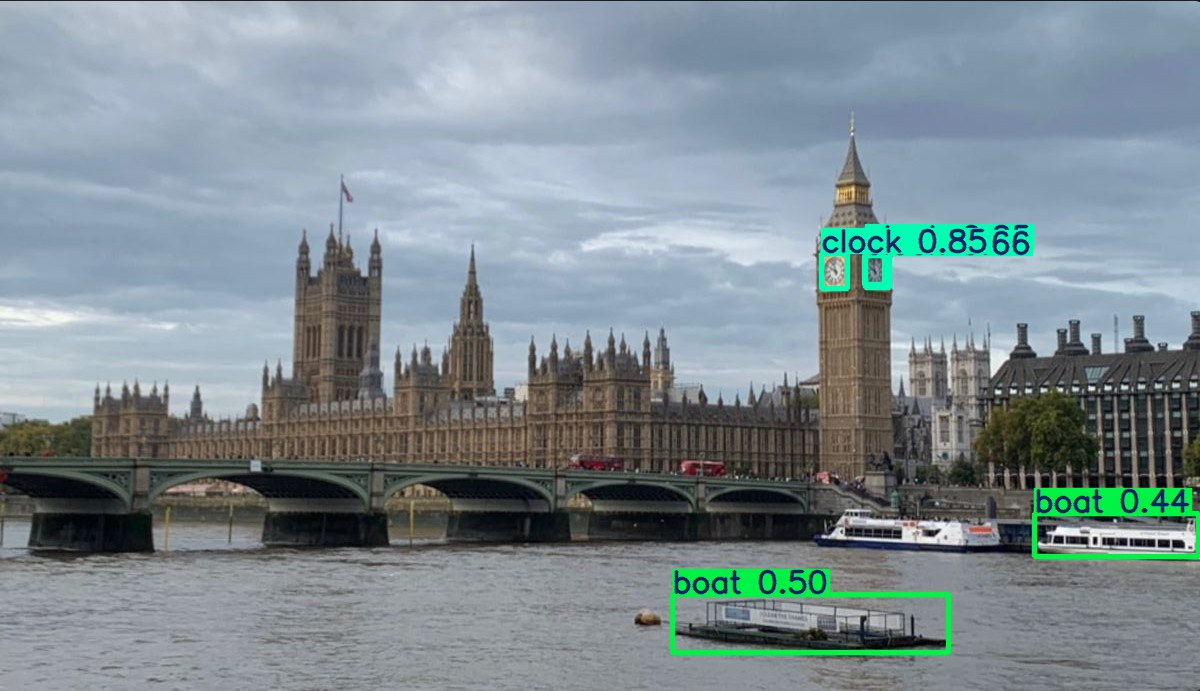

In [6]:
results = model("image.jpg")
results[0].show()

In [9]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("runs/detect/predict/image.jpg")

if img is not None:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis("off")
elif cv2.getBuildInformation().find('libjpeg') == -1:
    print("Error: OpenCV could not find libjpeg. This might be why imread failed.")
else:
    print("""Error: Could not load image. Make sure 'runs/detect/predict/image.jpg' exists and is accessible.
           If YOLO model has no detections, it might not save the image. Check previous cells output.""")

Error: Could not load image. Make sure 'runs/detect/predict/image.jpg' exists and is accessible.
           If YOLO model has no detections, it might not save the image. Check previous cells output.


In [10]:
!ls runs/detect/predict


ls: cannot access 'runs/detect/predict': No such file or directory


In [11]:
results = model("image.jpg", save=True)


image 1/1 /content/image.jpg: 384x640 (no detections), 7.6ms
Speed: 3.0ms preprocess, 7.6ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict


In [12]:
!ls runs/detect

predict


In [13]:
!ls runs/detect/predict

image.jpg


(np.float64(-0.5), np.float64(1199.5), np.float64(690.5), np.float64(-0.5))

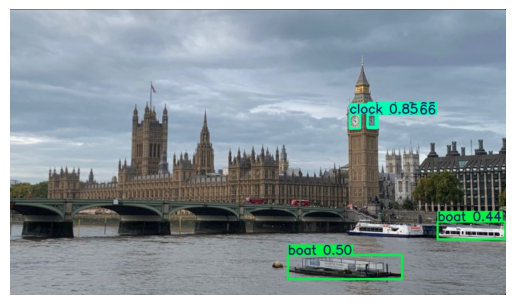

In [14]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("runs/detect/predict/image.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

In [15]:
for box in results[0].boxes:
    print(model.names[int(box.cls)])

In [16]:
for box in results[0].boxes:
    cls = model.names[int(box.cls)]
    conf = float(box.conf)
    print(cls, conf)

In [17]:
from google.colab import files
files.download("runs/detect/predict/image.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

(np.float64(-0.5), np.float64(1199.5), np.float64(690.5), np.float64(-0.5))

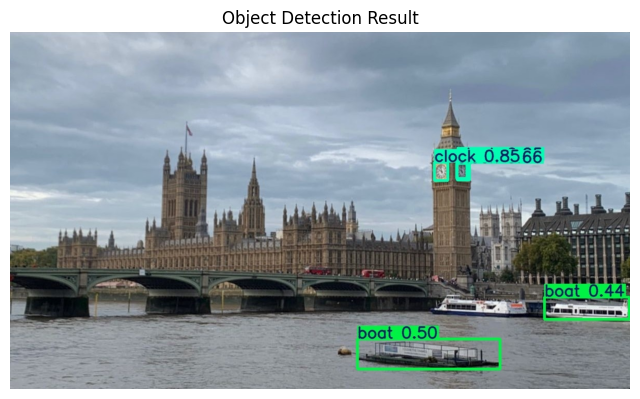

In [18]:
plt.figure(figsize=(8,8))
plt.imshow(img)
plt.title("Object Detection Result")
plt.axis("off")

In [19]:
uploaded = files.upload()


Saving people&cars.jpg to people&cars.jpg



image 1/1 /content/people&cars.jpg: 512x640 5 persons, 6 cars, 272.4ms
Speed: 11.3ms preprocess, 272.4ms inference, 39.3ms postprocess per image at shape (1, 3, 512, 640)


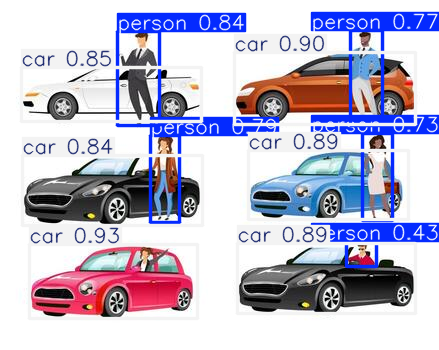

In [20]:
results = model("people&cars.jpg")
results[0].show()

In [21]:
model = YOLO("yolov8l.pt")

In [22]:
uploaded = files.upload()


Saving people&cars.jpg to people&cars (1).jpg



image 1/1 /content/people&cars.jpg: 512x640 6 persons, 6 cars, 54.0ms
Speed: 1.9ms preprocess, 54.0ms inference, 1.2ms postprocess per image at shape (1, 3, 512, 640)


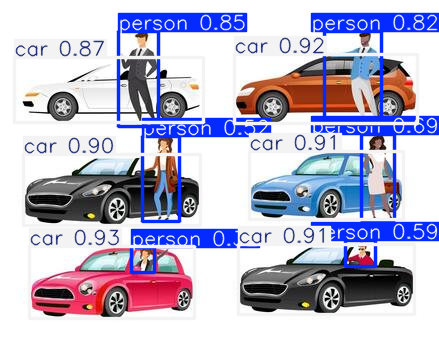

In [23]:
results = model("people&cars.jpg")
results[0].show()

In [24]:
from google.colab import files
uploaded = files.upload()

Saving traffic.mp4 to traffic.mp4


In [25]:
results = model("traffic.mp4", save=True)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/507) /content/traffic.mp4: 640x384 3 persons, 23 cars, 2 motorcycles, 2 buss, 2 trucks, 56.3ms
video 1/1 (frame 2/507) /content/traffic.mp4: 640x384 3 persons, 24 cars, 2 motorcycles, 1 bus, 1 truck, 40.3ms
video 1/1 (frame 3/507) /content/traffic.mp4: 640x384 3 persons, 26 cars, 3 motorcycles, 1 bus, 2 trucks, 39.8ms
video 1/1 (frame 4/507) /content/traffic.mp4: 640x384 3 persons, 25 cars, 2 motorcycles, 1 bus, 1 truck, 39.7ms
video 1

In [26]:
!ls runs/detect/predict

image.jpg


In [27]:
!ls runs/detect

predict  predict2


In [28]:
!ls runs/detect/predict2

traffic.avi


In [29]:
from IPython.display import Video

Video("runs/detect/predict/traffic.mp4")

ValueError: To embed videos, you must pass embed=True (this may make your notebook files huge)
Consider passing Video(url='...')

In [30]:
from IPython.display import Video

Video("runs/detect/predict2/traffic.avi")

In [ ]:
!ffmpeg -i runs/detect/predict2/traffic.avi output.mp4

In [ ]:
!ffmpeg -i runs/detect/predict2/traffic.avi output.mp4

In [ ]:
from IPython.display import Video
Video("output.mp4")

In [31]:
!ls runs/detect

predict  predict2


In [32]:
!ls runs/detect/predict2

traffic.avi


In [33]:
!ffmpeg -i runs/detect/predict2/traffic.avi output.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [34]:
from IPython.display import Video
Video("output.mp4")

In [35]:
!ffmpeg -i runs/detect/predict2/traffic.avi detected_video.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [36]:
from IPython.display import HTML

HTML("""
<video width="640" height="480" controls>
  <source src="detected_video.mp4" type="video/mp4">
</video>
""")

In [37]:
from google.colab import files
files.download("detected_video.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/1 /content/people&cars.jpg: 512x640 5 persons, 6 cars, 53.4ms
Speed: 2.3ms preprocess, 53.4ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/predict2


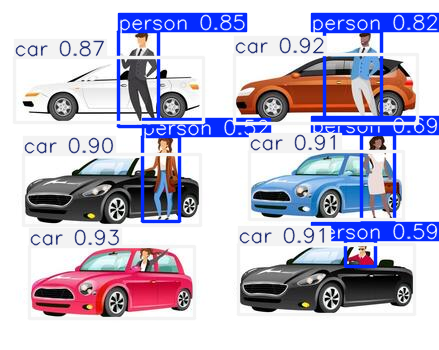

In [38]:
confidence_threshold = 0.5   # you can change this value

results = model("people&cars.jpg", conf=confidence_threshold, save=True)
results[0].show()

In [39]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")


image 1/1 /content/people&cars.jpg: 512x640 6 persons, 6 cars, 66.5ms
Speed: 3.6ms preprocess, 66.5ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/predict3


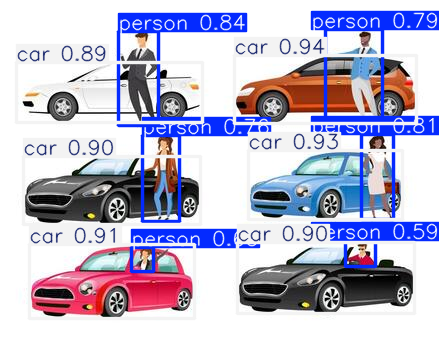

In [40]:
confidence_threshold = 0.5   # you can change this value

results = model("people&cars.jpg", conf=confidence_threshold, save=True)
results[0].show()

In [41]:
from collections import Counter

objects = []

for box in results[0].boxes:
    cls = model.names[int(box.cls)]
    objects.append(cls)

counts = Counter(objects)

print("Object Counts:")
for obj, count in counts.items():
    print(obj, ":", count)

Object Counts:
car : 6
person : 6


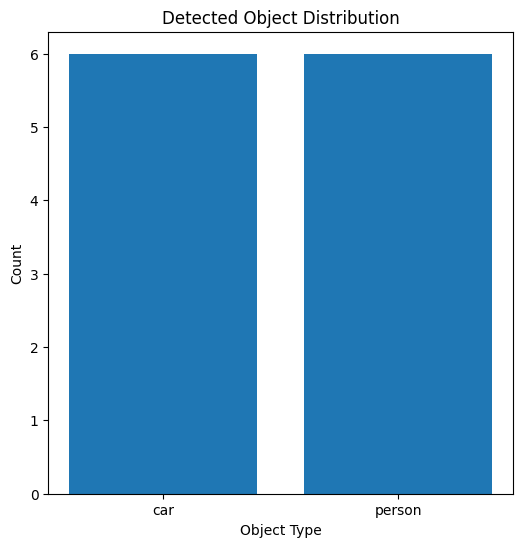

In [42]:
import matplotlib.pyplot as plt

labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(6,6))
plt.bar(labels, values)
plt.xlabel("Object Type")
plt.ylabel("Count")
plt.title("Detected Object Distribution")
plt.show()

In [43]:
print("Detected Objects Summary")
print("------------------------")

total = 0
for obj, count in counts.items():
    print(obj, ":", count)
    total += count

print("Total Objects Detected:", total)

Detected Objects Summary
------------------------
car : 6
person : 6
Total Objects Detected: 12
